# 12 — Exploring Latent Spaces and Interpolation in VAEs

## 📚 Learning Objectives

By completing this notebook, you will:
- Train a VAE and **map its latent space**: see that digit classes cluster without ever showing the model a label
- **Interpolate** between two real digits in latent space and decode the morph
- Sample the prior for novel digits — the three standard latent-space operations

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 04 (the VAE) and Course 04 (AIAT 114) — Unit 4, lesson 03, whose PCA is what makes a high-dimensional latent space visible in 2-D.

**Used later in:** Course 10 — Unit 3, lessons 01 and 03, which use interpolation to morph digits across classes.

---

## Introduction

The latent space is *the* reason to use a VAE: a smooth, low-dimensional space where every point decodes to a plausible image. Three operations demonstrate that structure, and this notebook runs all three on a VAE you train:

1. **Visualization** — encode many images, project the latent vectors to 2-D, color by class
2. **Interpolation** — walk a straight line between two images' latent codes and decode each step
3. **Sampling** — decode random draws from the prior N(0, I)

---

## 🌍 Why this lesson exists — what else lives in a latent space

Carlini et al. (2023, arXiv 2301.13188), *Extracting Training Data from Diffusion Models*, extracted **over a thousand training examples** — including photographs of individual people and trademarked company logos — from state-of-the-art generators including Stable Diffusion, using a generate-and-filter pipeline. The latent space you are about to explore is not only a space of *new* images. Parts of it decode to memorised training data, and the smoothness that makes interpolation work is what lets you walk to them.

**What goes wrong without this:** the reason to prefer a VAE over a plain autoencoder is that the KL term makes its latent space *continuous and sampleable* — every point decodes to something plausible. Drop that term and the space becomes a scatter of isolated memorised islands: compression still works, but sampling produces noise and interpolation walks through garbage.


In [1]:
# WHAT/WHY: train the example-04 VAE on MNIST (all ten classes) — the model
# whose latent space we then visualize, interpolate through, and sample.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 16; BATCH = 128; EPOCHS = 6

# ── Data: 12,800 MNIST digits — small enough for CPU, varied enough to map ──
dataset = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# ── Model: encoder → (mu, logvar) → sampled z → decoder (example 04's VAE) ──
class VAE(nn.Module):
    def __init__(self, z=LATENT):
        super().__init__()
        self.enc    = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec    = nn.Sequential(nn.Linear(z, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    def decode(self, z):
        return self.dec(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, logvar = self.encode(x)
        # Reparameterization trick: sample z so gradients can flow through mu/logvar.
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar

# ── Training: minimize reconstruction error + KL term (the ELBO) ──────────
vae = VAE(); opt = optim.Adam(vae.parameters(), lr=1e-3)
for epoch in range(EPOCHS):
    total = 0.0
    for x, _ in loader:
        recon, mu, logvar = vae(x)
        loss = (F.binary_cross_entropy(recon, x, reduction='sum')
                - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} — avg loss/image: {total/len(loader):.2f}")
vae.eval()


Epoch 1/6 — avg loss/image: 246.94


Epoch 2/6 — avg loss/image: 174.00


Epoch 3/6 — avg loss/image: 151.33


Epoch 4/6 — avg loss/image: 139.61


Epoch 5/6 — avg loss/image: 133.27


Epoch 6/6 — avg loss/image: 128.95


VAE(
  (enc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
  )
  (mu): Linear(in_features=256, out_features=16, bias=True)
  (logvar): Linear(in_features=256, out_features=16, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

## Operation 1 — Visualize the Latent Space

We encode 3,000 **test** digits (never seen in training), take their latent means μ, project the 16-D vectors to 2-D with PCA, and color each point by its true label — which the VAE never saw. Class clusters appearing anyway means the latent space organized itself around what digits *look like*.


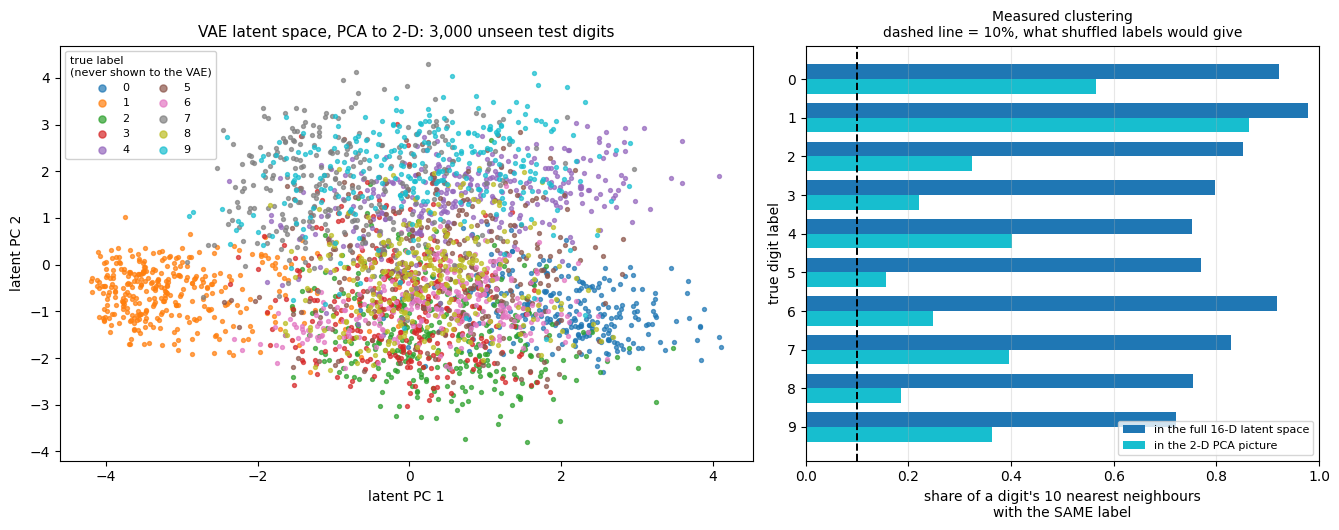

Mean same-class neighbour rate, 16-D latent space: 83.0%
Mean same-class neighbour rate, 2-D PCA picture  : 37.9%
Chance level with ten classes                    : 10%

per class:  0:92%  1:98%  2:85%  3:80%  4:75%  5:77%  6:92%  7:83%  8:75%  9:72%
The VAE was never shown a label, so any rate above 10% is structure it
found on its own. The gap between the two bars per class is what the 2-D
picture throws away — read the scatter with that gap in mind.


In [2]:
# WHAT/WHY: encode unseen test digits and plot their latent vectors in 2-D,
# colored by true label — checking whether the latent space groups digits by
# class without ever having been given a label.
from sklearn.decomposition import PCA

test_ds = torchvision.datasets.MNIST('./data/mnist', train=False, transform=T.ToTensor())
imgs   = torch.stack([test_ds[i][0] for i in range(3000)])
labels = np.array([test_ds[i][1] for i in range(3000)])

# ── Encode: use the latent MEAN mu as each image's coordinates ────────────
with torch.no_grad():
    mu, _ = vae.encode(imgs)
z = mu.numpy()

# ── Project 16-D → 2-D with PCA for plotting ──────────────────────────────
z2 = PCA(n_components=2).fit_transform(z)

# ── MEASURE the clustering instead of asserting it ────────────────────────
# For each digit, look at its 10 nearest neighbours and count how many carry
# the same label. With ten classes, shuffled labels would give about 10%.
# We measure twice: in the FULL 16-D latent space, and in the 2-D picture,
# because the picture is a projection and throws information away.
from sklearn.neighbors import NearestNeighbors

def same_class_neighbour_rate(coords, k=10):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(coords)   # +1: a point is its own neighbour
    idx = nn.kneighbors(coords, return_distance=False)[:, 1:]
    return (labels[idx] == labels[:, None]).mean(axis=1)

rate16 = same_class_neighbour_rate(z)
rate2  = same_class_neighbour_rate(z2)
CHANCE = 0.1

cmap = plt.get_cmap('tab10')
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.4),
                               gridspec_kw=dict(width_ratios=[1.35, 1]))
for d in range(10):                    # one scatter call per class → a real legend
    m = labels == d
    axL.scatter(z2[m, 0], z2[m, 1], s=8, alpha=0.7, color=cmap(d), label=str(d))
axL.set_title("VAE latent space, PCA to 2-D: 3,000 unseen test digits", fontsize=11)
axL.set_xlabel("latent PC 1"); axL.set_ylabel("latent PC 2")
axL.legend(title="true label\n(never shown to the VAE)", fontsize=8, title_fontsize=8,
           ncol=2, loc='upper left', markerscale=1.8, framealpha=0.9)

per_class16 = [rate16[labels == d].mean() for d in range(10)]
per_class2  = [rate2[labels == d].mean() for d in range(10)]
ys = np.arange(10); h = 0.38
axR.barh(ys - h/2, per_class16, h, color='tab:blue',   label=f'in the full 16-D latent space')
axR.barh(ys + h/2, per_class2,  h, color='tab:cyan',   label='in the 2-D PCA picture')
axR.axvline(CHANCE, color='black', ls='--', lw=1.4)
axR.set_yticks(ys); axR.set_yticklabels(range(10)); axR.invert_yaxis()
axR.set_xlim(0, 1.0); axR.set_xlabel("share of a digit's 10 nearest neighbours\nwith the SAME label")
axR.set_ylabel("true digit label")
axR.set_title(f"Measured clustering\ndashed line = {CHANCE:.0%}, what shuffled labels would give",
              fontsize=10)
axR.legend(fontsize=8, loc='lower right'); axR.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Mean same-class neighbour rate, 16-D latent space: {rate16.mean():.1%}")
print(f"Mean same-class neighbour rate, 2-D PCA picture  : {rate2.mean():.1%}")
print(f"Chance level with ten classes                    : {CHANCE:.0%}")
print("\nper class:  " + "  ".join(f"{d}:{r:.0%}" for d, r in enumerate(per_class16)))
print("The VAE was never shown a label, so any rate above 10% is structure it")
print("found on its own. The gap between the two bars per class is what the 2-D")
print("picture throws away — read the scatter with that gap in mind.")


**Read the scatter with the bars beside it, never on its own.**

*The scatter.* One colour per true digit, and the VAE was never shown a single one of those labels — it only ever saw pixels. The 1s (orange) have taken over the whole left side as a clean, isolated island; that is the clearest structure on the plot, and it makes sense, because a 1 is the least ink and the least like anything else. Everything else is a crowded middle where colours interleave, with 0s (blue) leaning right and 3s/5s/8s piled through the centre. Judged by eye alone, you would call this "one cluster and a mush".

*The bars.* That eye judgement is wrong, and this is why the measurement is here. Take any test digit, look at its ten nearest neighbours **in the full 16-dimensional latent space**, and count how many share its label. If the space carried no class information the answer would be about 10%. It is far above that for every class — so the space really has organised itself by digit identity, without labels, including for the classes that look like a mush in the picture.

*The gap between the two bars is the lesson.* The lighter bar measures the same thing in the 2-D picture you are looking at, and it is lower for almost every class. Those are neighbours that are genuinely close in 16-D and got scattered apart by the projection. The mush is largely an artefact of squashing sixteen dimensions onto a page — which is exactly the warning in "Where this breaks" below, here with a number attached.

## Operation 2 — Interpolate Between Two Digits

Pick a real **3** and a real **8** from the test set, encode both to latent vectors z₁ and z₂, then decode points along the straight line z(α) = (1−α)·z₁ + α·z₂. Every intermediate point decodes to a plausible digit-like image — that smoothness is what the VAE's KL regularization bought us.


In [3]:
# WHAT/WHY: encode two real digits, walk the straight line between their
# latent codes, and decode each step — the classic latent-interpolation morph.

# ── Find a 3 and an 8 in the test set ─────────────────────────────────────
img_a = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 3)
img_b = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8)

# ── Encode both to their latent means ─────────────────────────────────────
with torch.no_grad():
    z_a, _ = vae.encode(img_a.unsqueeze(0))
    z_b, _ = vae.encode(img_b.unsqueeze(0))

# ── Decode 10 evenly spaced points along the line z_a → z_b ───────────────
steps = torch.linspace(0, 1, 10)
with torch.no_grad():
    morphs = torch.cat([vae.decode((1 - a) * z_a + a * z_b) for a in steps])

# No figure here on purpose. The decoded path is drawn ONCE, in the next cell,
# directly above the pixel-space blend it is supposed to beat — one picture the
# class can compare, instead of the same morph shown twice.
print(f"Decoded {len(steps)} frames along the straight line from z(real 3) to z(real 8).")
print("The claim to test: a PIXEL-space blend of the same two images would show a")
print("ghostly double exposure, while the latent path stays on coherent digits.")
print("The next cell computes both paths and puts them in one figure.")


Decoded 10 frames along the straight line from z(real 3) to z(real 8).
The claim to test: a PIXEL-space blend of the same two images would show a
ghostly double exposure, while the latent path stays on coherent digits.
The next cell computes both paths and puts them in one figure.


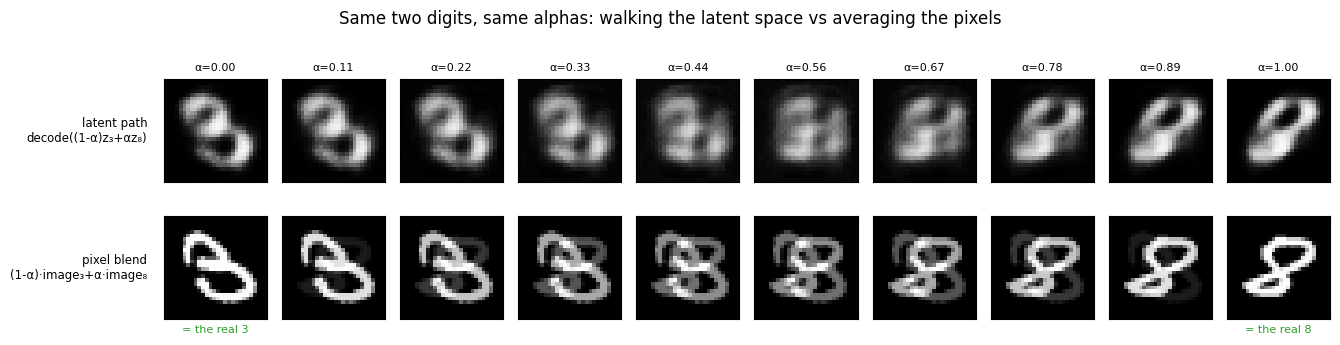

alpha   |latent - blend|   ambiguous pixels: latent / blend
0.00        0.112              0.251  /  0.084
0.11        0.106              0.277  /  0.093
0.22        0.108              0.319  /  0.235
0.33        0.114              0.357  /  0.261
0.44        0.121              0.392  /  0.276
0.56        0.122              0.374  /  0.272
0.67        0.114              0.347  /  0.258
0.78        0.103              0.292  /  0.227
0.89        0.094              0.247  /  0.085
1.00        0.093              0.207  /  0.065

mean        0.109              0.306  /  0.186

|latent - blend| = how far the decoded frame is from the naive average of
the two pictures. It is largest in the MIDDLE, where averaging would give a
ghost: that is where the two paths genuinely disagree.
Ambiguous = share of pixels between 0.2 and 0.8 (neither ink nor background).
Read that column carefully - it does NOT say what you might expect.


In [4]:
# WHAT/WHY: the cell above CLAIMS a pixel-space blend would look like a ghostly
# double image. Do not take that on trust - compute it and put the two paths in
# one figure, top row latent, bottom row pixels, same alphas.
mid_lat, mid_pix, from_blend = [], [], []
fig, axes = plt.subplots(2, len(steps), figsize=(13.5, 3.6))
for i, a in enumerate(steps):
    lat = morphs[i].squeeze().numpy()                  # decode((1-a)z_a + a z_b)
    pix = ((1 - a) * img_a + a * img_b).squeeze().numpy()   # the naive average
    axes[0, i].imshow(lat, cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(pix, cmap='gray', vmin=0, vmax=1)
    for r in (0, 1):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
    axes[0, i].set_title(f"α={a:.2f}", fontsize=8)
    # "ghostliness": share of pixels that are neither ink nor background
    mid_lat.append(float(((lat > 0.2) & (lat < 0.8)).mean()))
    mid_pix.append(float(((pix > 0.2) & (pix < 0.8)).mean()))
    # how far the decoder's answer is from simply averaging the two pictures
    from_blend.append(float(abs(lat - pix).mean()))
axes[0, 0].set_ylabel("latent path\ndecode((1-α)z₃+αz₈)", fontsize=8.5, rotation=0,
                      ha='right', va='center', labelpad=12)
axes[1, 0].set_ylabel("pixel blend\n(1-α)·image₃+α·image₈", fontsize=8.5, rotation=0,
                      ha='right', va='center', labelpad=12)
# Name the endpoints: on the pixel row they ARE the original test images, while
# on the latent row they are the VAE's reconstructions of those images.
axes[1, 0].set_xlabel("= the real 3", fontsize=8, color='tab:green')
axes[1, len(steps) - 1].set_xlabel("= the real 8", fontsize=8, color='tab:green')
plt.suptitle("Same two digits, same alphas: walking the latent space vs averaging the pixels")
plt.tight_layout(); plt.show()

print("alpha   |latent - blend|   ambiguous pixels: latent / blend")
# note: linspace(0,1,10) never lands exactly on 0.5 - the printed values are exact
for a, ml, mp, fb in zip(steps, mid_lat, mid_pix, from_blend):
    print(f"{a:.2f}        {fb:.3f}              {ml:.3f}  /  {mp:.3f}")
print(f"\nmean        {sum(from_blend)/len(from_blend):.3f}              "
      f"{sum(mid_lat)/len(mid_lat):.3f}  /  {sum(mid_pix)/len(mid_pix):.3f}")
print("\n|latent - blend| = how far the decoded frame is from the naive average of")
print("the two pictures. It is largest in the MIDDLE, where averaging would give a")
print("ghost: that is where the two paths genuinely disagree.")
print("Ambiguous = share of pixels between 0.2 and 0.8 (neither ink nor background).")
print("Read that column carefully - it does NOT say what you might expect.")

**Compare the two rows column by column.** The bottom row is arithmetic, and it looks like it: the 3 fades out while the 8 fades in, and in the middle frames **both digits are visible at once** — you can trace the 3's arcs and the 8's loops in the same picture. That is a double exposure, and it is not any digit at all. The top row never does this. Its middle frames are soft and ambiguous, but they are always *one* shape: the decoder has no way to output half of one digit plus half of another, because the only thing it knows how to do is turn a latent vector into a digit-shaped image.

**The endpoints are worth a second look too.** The bottom row starts and ends on the real, crisp test images. The top row starts and ends on the VAE's *reconstructions* of them, which are visibly blurrier — that is the reconstruction error of example 04, here in picture form rather than as a number.

**Now read the printed table, including the part that goes the wrong way.** The `|latent − blend|` column measures how far the decoded frame is from simply averaging the two pictures; it peaks in the middle frames (≈0.12) and is smallest at the far endpoint (0.093), which says the two paths agree most where the answer is nearly one of the originals and disagree most where averaging would produce the ghost. But it never reaches zero, even at α = 0 where the "blend" *is* the original image — so this number mixes "different path" with "VAE blur" and cannot separate them.

The ambiguity column is the real trap. A pixel between 0.2 and 0.8 is neither ink nor background, which sounds exactly like a ghost detector — and it reports **more** ambiguous pixels in the latent row (0.306) than in the pixel blend (0.186). The metric is not lying; it is answering a different question. A blend of two crisp digits keeps most pixels near black or white, while the VAE's decoder is soft *everywhere*. A number that sounds like it measures ghosting measured blur instead. The pictures are the evidence here; the columns beside them are a caution about trusting a plausible-sounding metric you have not validated.

Finally, be honest about the top row's weakness. Its middle frames are the blurriest and least convincing of the ten, exactly as the note below predicts: a straight line between two typical points in a Gaussian latent space passes through the low-density middle, so mid-path samples are systematically weaker. The latent path is clearly better than pixel averaging; it is not free of artefacts, and White (2016) proposes spherical interpolation precisely because of what you can see here.

## 💬 Discuss

1. Our 3 → 8 interpolation passed through digit-like shapes. Are those intermediate images "new digits", or averaged pixels wearing a decoder? Design a test that would separate the two answers using only what is in this notebook.
2. The PCA map shows 4s and 9s sharing territory. If you sold "generate a digit by clicking a point on this map", what does that overlap cost a user — and how would you communicate the limitation without losing the sale?
3. Carlini et al. recovered real people's photographs from a generator's latent space. Does the smoothness that makes interpolation work make memorisation *more* likely or *less*? Argue both sides before choosing.


## Operation 3 — Sample the Prior

Random z ~ N(0, I), decoded. (Example 11 covered sampling in depth; here it completes the latent-space toolkit.)


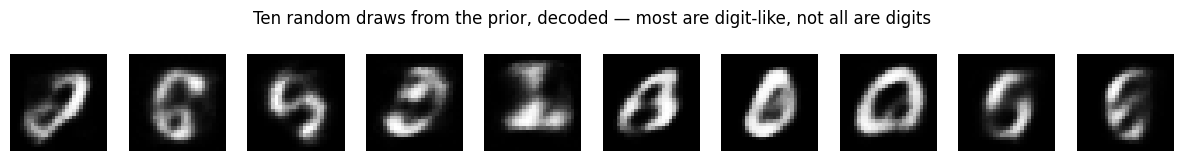

In [5]:
# WHAT/WHY: decode random draws from the prior — every point in latent space
# maps to some digit-like image, which is what makes the space explorable.
with torch.no_grad():
    samples = vae.decode(torch.randn(10, LATENT))


# Show the ten decoded samples in a row — each one is a brand-new digit.
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle("Ten random draws from the prior, decoded — most are digit-like, not all are digits")
plt.tight_layout(); plt.show()


**Read the row without being generous to it.** These ten images were never encoded from anything: each is a random point in the 16-dimensional prior, handed straight to the decoder. Most come out as recognisable digit shapes — that is the property the KL term bought, and a plain autoencoder would have returned noise here.

But count honestly. Several panels are shapes no one would write down as a number, and every panel carries the VAE's characteristic softness. "Every point decodes to something plausible" is true of this narrow domain and this small model, and the fraction that fails grows quickly on richer data — which is the first bullet of the note below.

## ⚠️ Where this breaks

**The 2-D picture is a PCA projection of a 16-D space.** Clusters that look separated in the projection may not be, and clusters that overlap may be perfectly separable in the twelve dimensions PCA discarded. Never make a claim about latent structure from the 2-D plot alone.

**Straight-line interpolation is the wrong path in a Gaussian latent space.** The straight line between two typical samples passes through the *low-density* middle, so mid-points are systematically blurrier and less typical than the endpoints. White (2016, arXiv 1609.04468) proposes spherical interpolation for exactly this reason — and the ghostly mid-frames above are the artefact, not a property of digits.

**"Every point decodes to something plausible" holds for a well-trained VAE on a narrow domain.** Our prior samples already include shapes that are not digits at all. On a wider dataset — faces, scenes, medical images — the fraction of prior samples that decode to nonsense grows, which is one reason production systems put diffusion inside the latent space instead of sampling it directly.

**Latent structure is not semantics.** The space organised itself by *visual similarity*, which is why 4s and 9s overlap. Nothing guarantees that a direction in this space corresponds to a human-meaningful attribute; Unit 3, example 03 measures how weak that guarantee is even when you deliberately optimise for it.


## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- White (2016) — [Sampling Generative Networks](https://arxiv.org/abs/1609.04468) *(interpolation done right, incl. spherical interpolation)*
- Higgins et al. (2017) — [β-VAE](https://openreview.net/forum?id=Sy2fchgcx) *(making latent dimensions interpretable)*
- Härkönen et al. (2020) — [GANSpace: Discovering Interpretable GAN Controls](https://arxiv.org/abs/2004.02546) *(PCA on latent space finds human-meaningful directions)*

**Looking ahead:** diffusion models — today's top image generators — are taught hands-on in **Unit 3, example 04**; their "latent space" is the noise process itself.


## 📝 Summary

In **12 — Exploring Latent Spaces and Interpolation** you ran the three standard latent-space operations on a VAE you trained: the 2-D map of 3,000 unseen digits showed class structure emerging without labels, the 3 → 8 interpolation decoded to a smooth morph through plausible digit shapes, and prior samples produced novel digits. This closes Unit 1's generative-fundamentals toolkit; Unit 2 applies generation to text, and Unit 3 (example 04) introduces diffusion models.
